# Upper Limits Contour

In [1]:
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import sys, os
from astropy.time import Time
import numpy as np

ROOT = '/home/liangrd/optical_data'
CANDIDATES = Table.read("/home/liangrd/Follow_up/Candidates.csv")

In [111]:
def plot_limits_contour(ROOT,candidates,bins_dt=15,bins_mag=12):
    all_photometry = Table()
    for target, T0 in zip(candidates['EP Name'],candidates['Obs Time']):
        T0 = Time(T0)
        try:
            photometry_i = Table.read(os.path.join(ROOT,target,'pipeline','photometry.csv'))
            if len(photometry_i) > 0:
                photometry_i['dt'] = photometry_i['mean_mjd'] - T0.mjd
                photometry_i = photometry_i[photometry_i['message']=='ok']
                all_photometry = vstack((all_photometry,photometry_i))
        except Exception as e:
            print(f"ERROR {e}")
            continue
    
    # =========================
    # 2. 准备绘图
    # =========================
    fig, ax = plt.subplots(figsize=(8, 5))

    bands = np.unique(all_photometry['band'])

    # 👉 定义“单色 colormap”
    cmap_dict = {
        'g': 'Greens',
        'r': 'Blues',
        'i': 'Reds',
        'w': 'Purples'
    }

    for i, band in enumerate(bands):
        phot_band = all_photometry[all_photometry['band'] == band]

        if len(phot_band) < 5:
            continue

        dt = np.array(phot_band['dt'])
        mag = np.array(phot_band['upper_limit'])

        mask = np.isfinite(dt) & np.isfinite(mag)
        dt = dt[mask]
        mag = mag[mask]
        
        mag_range = np.max(mag) - np.min(mag)

        # -------------------------
        # density
        # -------------------------
        h = ax.hist2d(
            dt,
            mag,
            bins=[bins_dt, np.min([bins_mag,int(mag_range/1.)])],
            cmap=cmap_dict.get(band, 'Greys'),
            density=True,
            norm=plt.matplotlib.colors.LogNorm(),
            alpha=0.8  # ⭐ 关键：叠加透明度
        )

        # legend trick
        ax.plot([], [], color=plt.get_cmap(cmap_dict.get(band, 'Greys'))(0.7),
                label=f"{band}-band")

    # =========================
    # 3. 美化
    # =========================
    ax.set_xlabel("$\Delta t$ (days)")
    ax.set_ylabel("Limiting Magnitude")
    ax.invert_yaxis()
    ax.tick_params('both',direction='in')

    ax.legend()
    plt.savefig("/home/liangrd/Follow_up/results/lim_mag_density.png",bbox_inches='tight',dpi=300)
    
    
def plot_limits_hist1d(ROOT,candidates):
    all_photometry = Table()
    for target, T0 in zip(candidates['EP Name'],candidates['Obs Time']):
        T0 = Time(T0)
        try:
            photometry_i = Table.read(os.path.join(ROOT,target,'pipeline','photometry.csv'))
            if len(photometry_i) > 0:
                photometry_i['dt'] = photometry_i['mean_mjd'] - T0.mjd
                photometry_i = photometry_i[photometry_i['message']=='ok']
                all_photometry = vstack((all_photometry,photometry_i))
        except Exception as e:
            print(f"ERROR {e}")
            continue

    # =========================
    # 2. 准备绘图
    # =========================

    bands = np.unique(all_photometry['band'])

    # 👉 定义“单色 colormap”
    c_dict = {
        'g': '#3288bd',
        'r': '#fdae61',
        'i': '#d53e4f',
        'z': '#9e0142',
        'w': '#e6f598'
    }
    
    data_dict = dict()
    nsub = 0
    plot_bands = []

    for i, band in enumerate(bands):
        phot_band = all_photometry[all_photometry['band'] == band]

        if len(phot_band) < 5:
            continue
        else:
            nsub += 1
            data_dict[band] = phot_band
            plot_bands.append(band)
            
    plt.rcParams["font.size"] = 15
    plt.rcParams["font.family"] = 'serif'
    # fig = plt.figure(figsize=(3.5*nsub, 5))
    # gs = fig.add_gridspec(1, nsub, wspace=0.05)
    # ax = gs.subplots(sharey=True)
    fig, ax = plt.subplots(figsize=(5, 5))
    for i, band in enumerate(plot_bands):
        bins = int(np.sqrt(len(data_dict[band])))
        ax.hist(data_dict[band]['upper_limit'],color=c_dict[band],bins=bins,density=True,alpha=0.7,label=f"${band}$")
        ax.hist(data_dict[band]['upper_limit'],color='k',bins=bins,histtype='step',density=True)
    ax.set_xlabel("$m_{\mathrm{lim}}$")
    ax.set_yticks([])
    ax.tick_params('both',direction='in')
    ax.legend(fontsize=12)
    plt.savefig("/home/liangrd/Follow_up/results/lim_mag_hist1d.png",bbox_inches='tight',dpi=300)
    
    

<>:65: SyntaxWarning: invalid escape sequence '\D'
<>:127: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\D'
<>:127: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3880504/779122898.py:65: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel("$\Delta t$ (days)")
/tmp/ipykernel_3880504/779122898.py:127: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$m_{\mathrm{lim}}$")


ERROR [Errno 2] No such file or directory: '/home/liangrd/optical_data/EP260308a/pipeline/photometry.csv'
ERROR [Errno 2] No such file or directory: '/home/liangrd/optical_data/EP260322a/pipeline/photometry.csv'


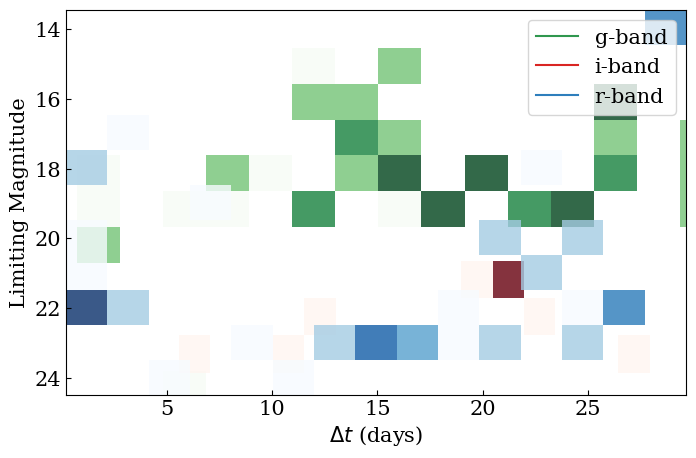

In [112]:
plot_limits_contour(ROOT,CANDIDATES)

ERROR [Errno 2] No such file or directory: '/home/liangrd/optical_data/EP260308a/pipeline/photometry.csv'
ERROR [Errno 2] No such file or directory: '/home/liangrd/optical_data/EP260322a/pipeline/photometry.csv'


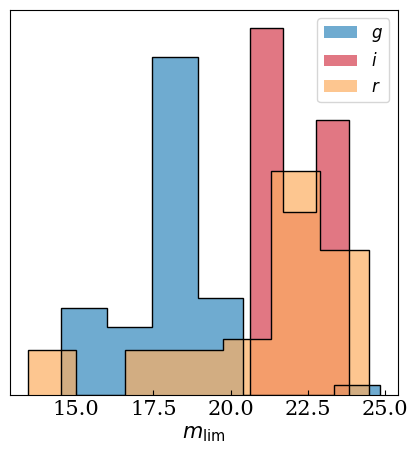

In [113]:
plot_limits_hist1d(ROOT,CANDIDATES)